In [55]:
from datetime import datetime, timezone, timedelta

from crlx import SIKULIAQ

In [56]:
import bottleneck
from datetime import datetime, timezone
import matplotlib.pyplot as plt
import os
import numpy as np
import pandas as pd
import requests
from requests.compat import urljoin
import warnings
from typing import Union

import xarray as xr

In [57]:
skq = SIKULIAQ(verbose = True)
edt = datetime.now(timezone.utc)
bdt = edt - timedelta(hours = 24)

In [29]:
#ldeo = skq.get_data('SensorFloat17', bdt=bdt, edt=edt)
#asp3 = skq.get_data('sensor_mixlg_11', bdt=bdt, edt=edt)

In [30]:
#met = skq.get_data('sensor_mixed_5', bdt=bdt, edt=edt)

In [31]:
#%matplotlib widget
#
#fig, ax = plt.subplots(2,1, figsize = (10,8))
#
#ax[0].scatter(ldeo['time'], ldeo['pco2'].where(ldeo['source_id'] == 0),label='Ldeo')
#ax[0].scatter(asp3['time'], asp3['equilibrator_pco2'].where(asp3['sample_source'] == 'Seawater'),label='Apollo')
#ax[0].grid()
#ax[0].legend()
#ax[0].set_title('SW')
#
#ax[1].scatter(ldeo['time'], ldeo['pco2'].where(ldeo['source_id'] == 1),label='Ldeo')
#ax[1].scatter(asp3['time'], asp3['equilibrator_pco2'].where(asp3['sample_source'] == 'Air'),label='Apollo')
#ax[1].grid()
#ax[1].legend()
#ax[1].set_title('Air')

In [58]:
apollo = skq.get_wet_lab_apollo(bdt, edt)
ldeo = skq.get_wet_lab_ldeo(bdt, edt)

In [34]:
plt.close('all')

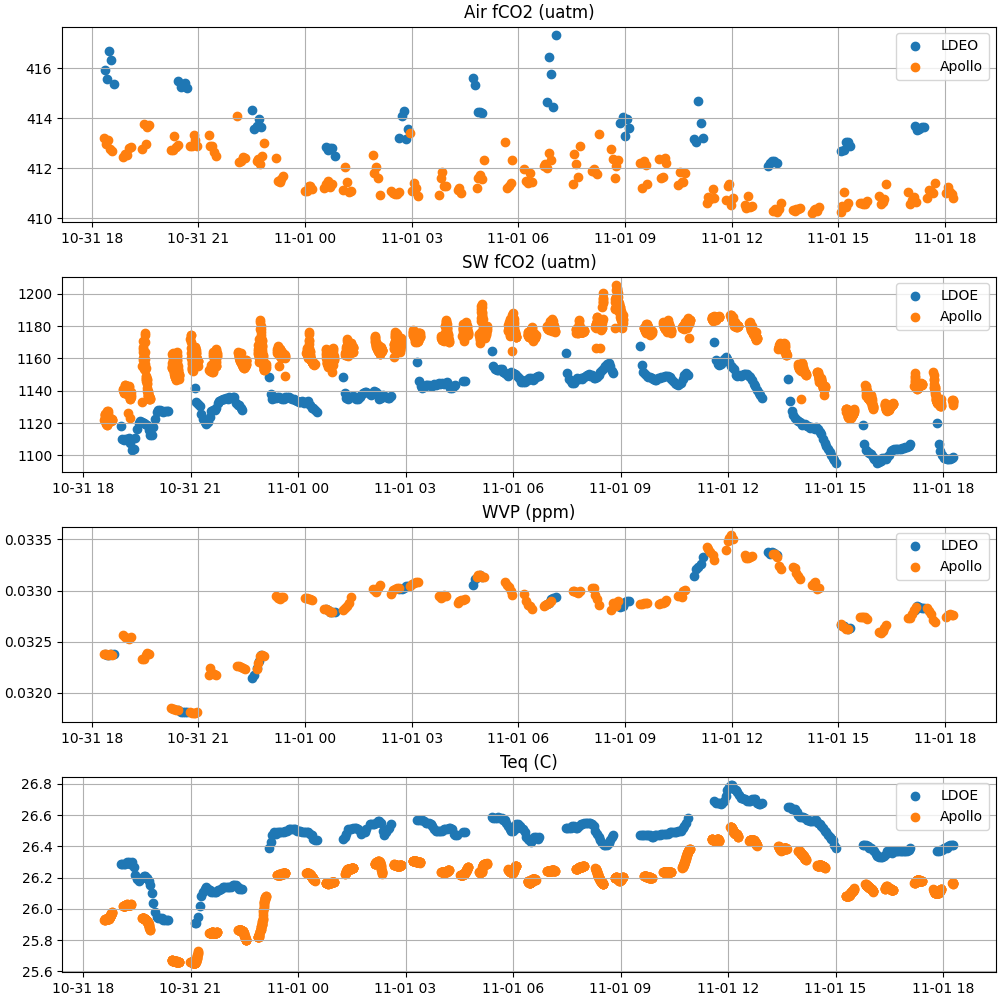

In [59]:
%matplotlib widget

fig, ax = plt.subplots(4,1, figsize = (10,10), constrained_layout = True)

ax[0].scatter(ldeo.time.where(ldeo.sample_source == 'air'), ldeo.fco2.where(ldeo.sample_source == 'air'),label="LDEO")
ax[0].scatter(apollo.time.where(apollo.sample_source == 'air'), apollo.fco2.where(apollo.sample_source == 'air'),label="Apollo")
ax[0].set_title('Air fCO2 (uatm)')
ax[0].legend()
ax[0].grid()

ax[1].scatter(ldeo.time.where(ldeo.sample_source == 'seawater'), ldeo.fco2.where(ldeo.sample_source == 'seawater'),label = 'LDOE')
ax[1].scatter(apollo.time.where(apollo.sample_source == 'seawater'), apollo.fco2.where(apollo.sample_source == 'seawater'),label = 'Apollo')
ax[1].set_title('SW fCO2 (uatm)')
ax[1].legend()
ax[1].grid()

ax[2].scatter(ldeo.time.where(ldeo.sample_source == 'air'), ldeo.water_vapor_pressure.where(ldeo.sample_source == 'air'),label="LDEO")
ax[2].scatter(apollo.time.where(apollo.sample_source == 'air'), apollo.water_vapor_pressure.where(apollo.sample_source == 'air'),label="Apollo")
ax[2].set_title('WVP (ppm)')
ax[2].legend()
ax[2].grid()

ax[3].scatter(ldeo.time.where(ldeo.sample_source == 'seawater'), ldeo.equilibrator_temperature_sbe38.where(ldeo.sample_source == 'seawater'),label = 'LDOE')
ax[3].scatter(apollo.time.where(apollo.sample_source == 'seawater'), apollo.apollo_sbe45_sea_water_temperature.where(apollo.sample_source == 'seawater'),label = 'Apollo')
ax[3].set_title('Teq (C)')
ax[3].legend()
ax[3].grid()

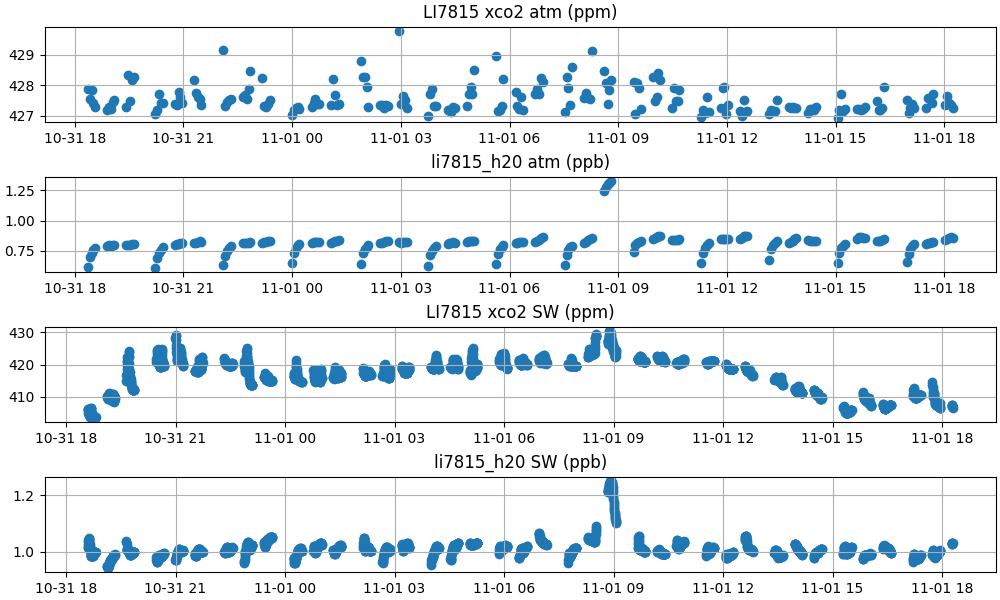

In [60]:
%matplotlib widget

fig, ax = plt.subplots(4,1, figsize = (10,6), constrained_layout = True)

ax[0].scatter(apollo.time.where(apollo.sample_source == 'air'), apollo.li7815_xco2.where(apollo.sample_source == 'air'),label="Apollo")
ax[0].set_title('LI7815 xco2 atm (ppm)')
ax[0].grid()

ax[1].scatter(apollo.time.where(apollo.sample_source == 'air'), apollo.li7815_h2o.where(apollo.sample_source == 'air'),label = 'Apollo')
ax[1].set_title('li7815_h20 atm (ppb)')
ax[1].grid()

ax[2].scatter(apollo.time.where(apollo.sample_source == 'seawater'), apollo.li7815_xco2.where(apollo.sample_source == 'seawater'),label="Apollo")
ax[2].set_title('LI7815 xco2 SW (ppm)')
ax[2].grid()

ax[3].scatter(apollo.time.where(apollo.sample_source == 'seawater'), apollo.li7815_h2o.where(apollo.sample_source == 'seawater'),label = 'Apollo')
ax[3].set_title('li7815_h20 SW (ppb)')
ax[3].grid()

In [67]:
apollo_re = apollo
apollo_re = apollo_re.sortby('time')
apollo_re = apollo_re.resample(time='20min').mean()

ldeo_re = ldeo
ldeo_re = ldeo_re.sortby('time')
ldeo_re = ldeo_re.resample(time='20min',skipna = True).mean()

delta_sw = ldeo_re.fco2.where(ldeo.sample_source == 'seawater')-apollo_re.fco2.where(apollo.sample_source == 'seawater')
delta_sw_x = ldeo_re.xco2_corr.where(ldeo.sample_source == 'seawater')-apollo_re.xco2_corr.where(apollo.sample_source == 'seawater')
delta_at = ldeo_re.fco2.where(ldeo.sample_source == 'air')-apollo_re.fco2.where(apollo.sample_source == 'air')
delta_at_x = ldeo_re.xco2_corr.where(ldeo.sample_source == 'air')-apollo_re.xco2_corr.where(apollo.sample_source == 'air')
delta_teq = ldeo_re.equilibrator_temperature_sbe38.where(ldeo.sample_source == 'seawater')-apollo_re.apollo_sbe45_sea_water_temperature.where(apollo.sample_source == 'seawater')

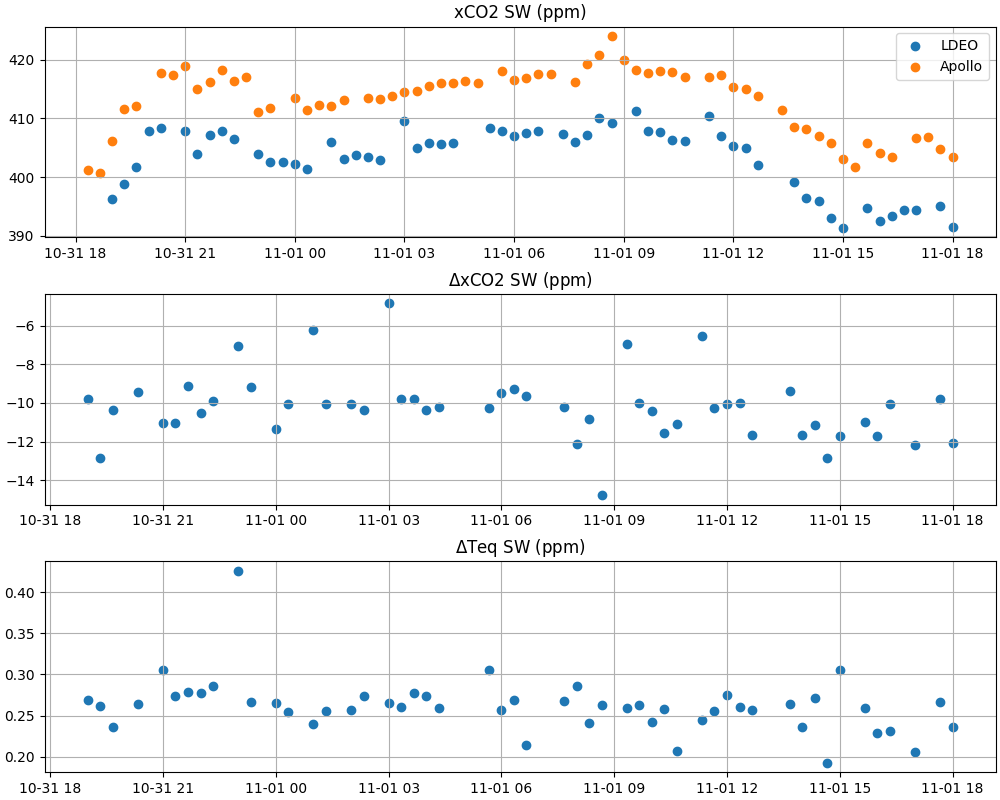

In [62]:
fig,ax = plt.subplots(3,1, figsize = (10,8), constrained_layout = True)
ax[0].scatter(ldeo_re.time.where(ldeo.sample_source == 'seawater'),ldeo_re.xco2_corr.where(ldeo.sample_source == 'seawater'),label="LDEO")
ax[0].scatter(apollo_re.time.where(apollo.sample_source == 'seawater'),apollo_re.xco2_corr.where(apollo.sample_source == 'seawater'),label="Apollo")
ax[0].legend()
ax[0].set_title('xCO2 SW (ppm)')
ax[0].grid()

ax[1].scatter(apollo_re.time.where(apollo.sample_source == 'seawater'),delta_sw_x)
ax[1].set_title('$\Delta$xCO2 SW (ppm)')
ax[1].grid()

ax[2].scatter(apollo_re.time.where(apollo.sample_source == 'seawater'),delta_teq)
ax[2].set_title('$\Delta$Teq SW (ppm)')
ax[2].grid()

plt.show()

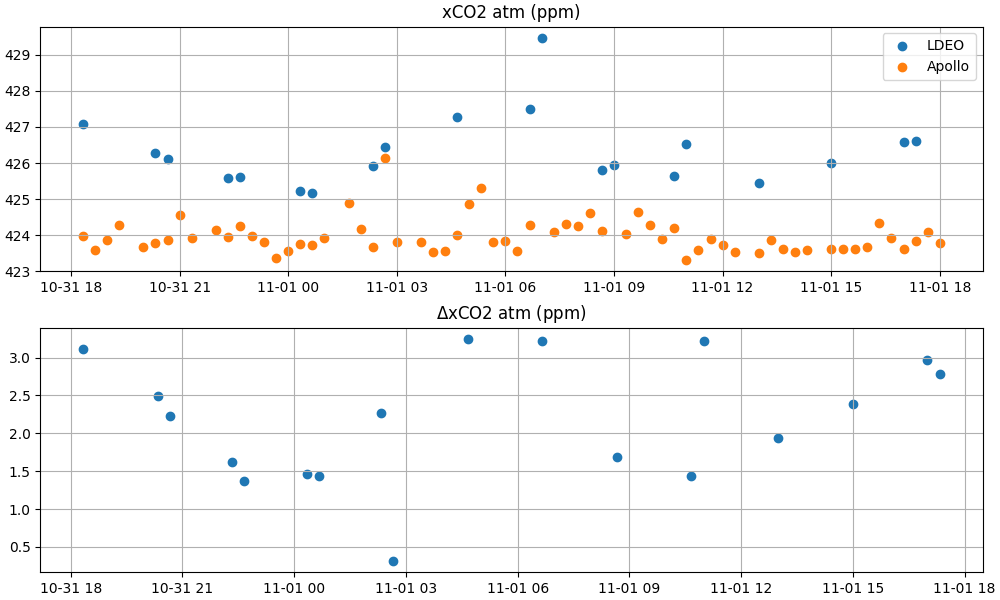

In [68]:
fig,ax = plt.subplots(2,1, figsize = (10,6), constrained_layout = True)
ax[0].scatter(ldeo_re.time.where(ldeo.sample_source == 'air'),ldeo_re.xco2_corr.where(ldeo.sample_source == 'air'),label="LDEO")
ax[0].scatter(apollo_re.time.where(apollo.sample_source == 'air'),apollo_re.xco2_corr.where(apollo.sample_source == 'air'),label="Apollo")
ax[0].legend()
ax[0].set_title('xCO2 atm (ppm)')
ax[0].grid()

ax[1].scatter(ldeo_re.time.where(apollo.sample_source == 'air'),delta_at_x)
ax[1].set_title('$\Delta$xCO2 atm (ppm)')
ax[1].grid()

plt.show()

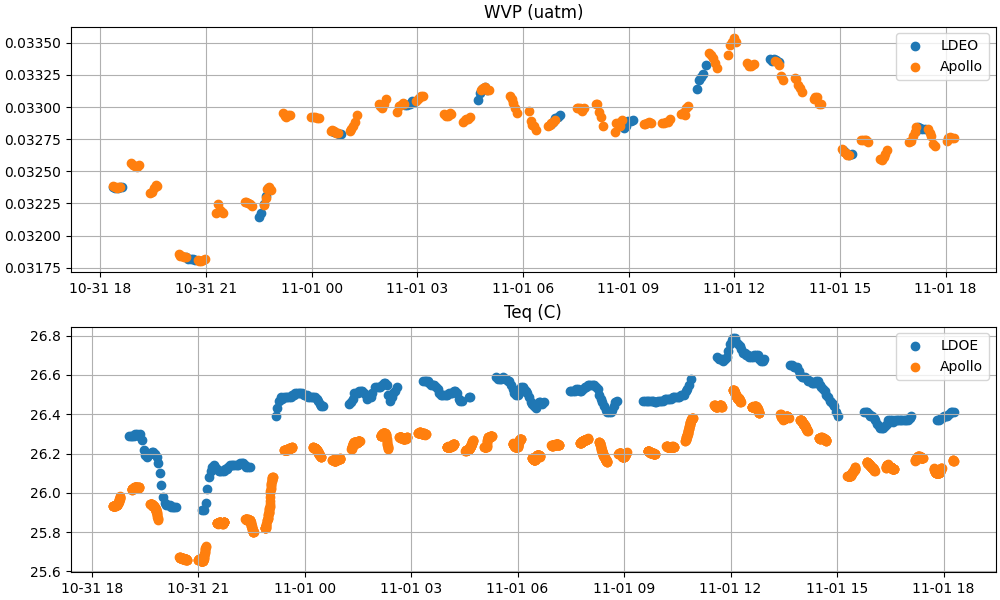

In [69]:
%matplotlib widget

fig, ax = plt.subplots(2,1, figsize = (10,6), constrained_layout = True)

ax[0].scatter(ldeo.time.where(ldeo.sample_source == 'air'), ldeo.water_vapor_pressure.where(ldeo.sample_source == 'air'),label="LDEO")
ax[0].scatter(apollo.time.where(apollo.sample_source == 'air'), apollo.water_vapor_pressure.where(apollo.sample_source == 'air'),label="Apollo")
ax[0].set_title('WVP (uatm)')
ax[0].legend()
ax[0].grid()

ax[1].scatter(ldeo.time.where(ldeo.sample_source == 'seawater'), ldeo.equilibrator_temperature_sbe38.where(ldeo.sample_source == 'seawater'),label = 'LDOE')
ax[1].scatter(apollo.time.where(apollo.sample_source == 'seawater'), apollo.apollo_sbe45_sea_water_temperature.where(apollo.sample_source == 'seawater'),label = 'Apollo')
ax[1].set_title('Teq (C)')
ax[1].legend()
ax[1].grid()

C:\Users\annar\AppData\Local\Temp\ipykernel_19396\2978542607.py:1: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig,ax = plt.subplots(2,1, figsize = (10,6), constrained_layout = True)


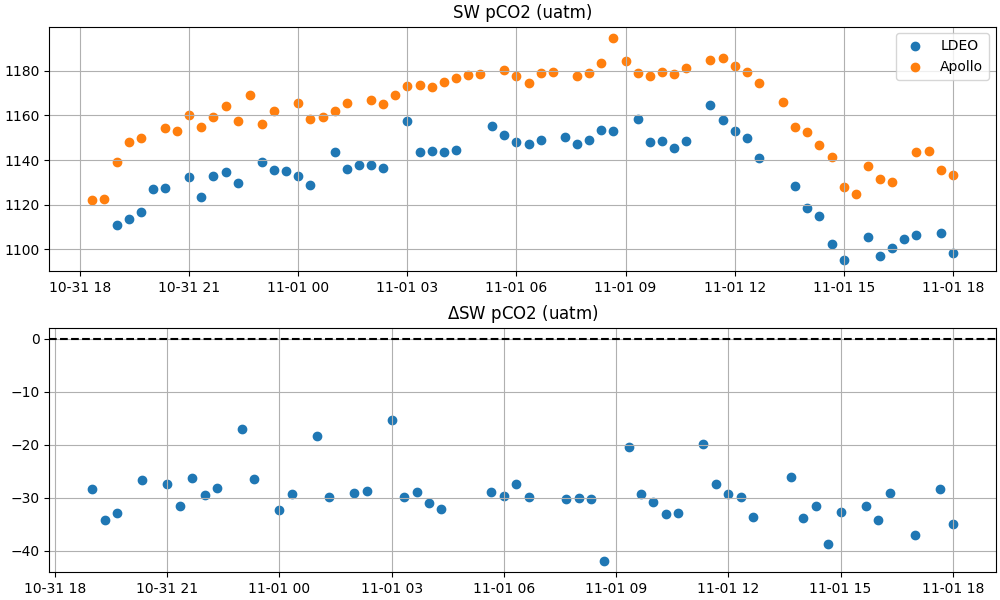

In [70]:
fig,ax = plt.subplots(2,1, figsize = (10,6), constrained_layout = True)
ax[0].scatter(ldeo_re.time.where(ldeo.sample_source == 'seawater'),ldeo_re.fco2.where(ldeo.sample_source == 'seawater'),label="LDEO")
ax[0].scatter(apollo_re.time.where(apollo.sample_source == 'seawater'),apollo_re.fco2.where(apollo.sample_source == 'seawater'),label="Apollo")
ax[0].legend()
ax[0].set_title('SW pCO2 (uatm)')
ax[0].grid()

ax[1].scatter(apollo_re.time.where(apollo.sample_source == 'seawater'),delta_sw,label="Delta")
ax[1].axhline(0, color = 'black',linestyle = '--')
ax[1].set_title('$\Delta$SW pCO2 (uatm)')
ax[1].grid()

plt.show()

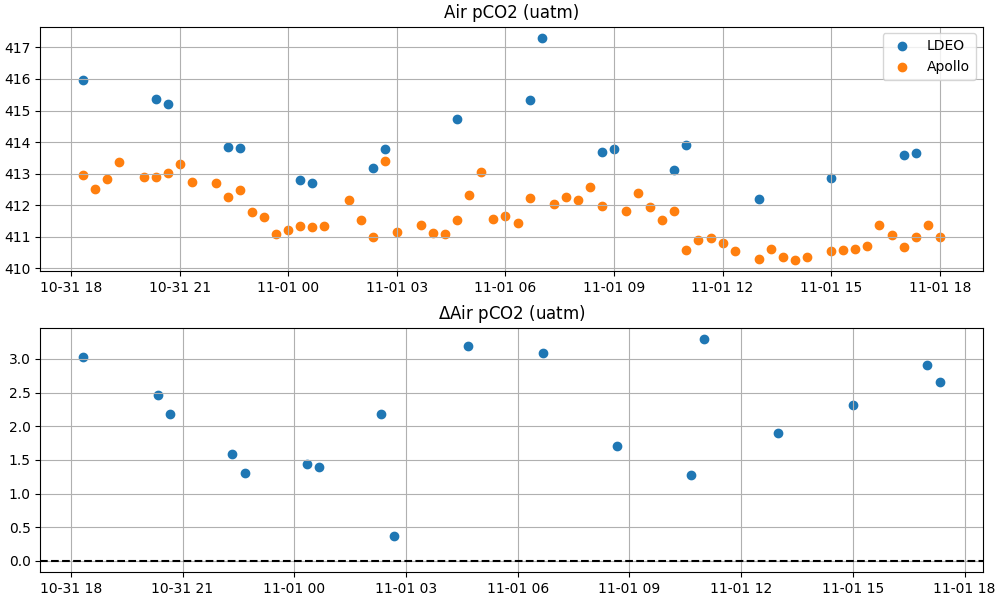

In [71]:
fig,ax = plt.subplots(2,1, figsize = (10,6), constrained_layout = True)
ax[0].scatter(ldeo_re.time.where(ldeo.sample_source == 'air'),ldeo_re.fco2.where(ldeo.sample_source == 'air'),label="LDEO")
ax[0].scatter(apollo_re.time.where(apollo.sample_source == 'air'),apollo_re.fco2.where(apollo.sample_source == 'air'),label="Apollo")
ax[0].legend()
ax[0].set_title('Air pCO2 (uatm)')
ax[0].grid()

ax[1].scatter(apollo_re.time.where(apollo.sample_source == 'air'),delta_at,label="Delta")
ax[1].axhline(0, color = 'black',linestyle = '--')
ax[1].set_title('$\Delta$Air pCO2 (uatm)')
ax[1].grid()

plt.show()

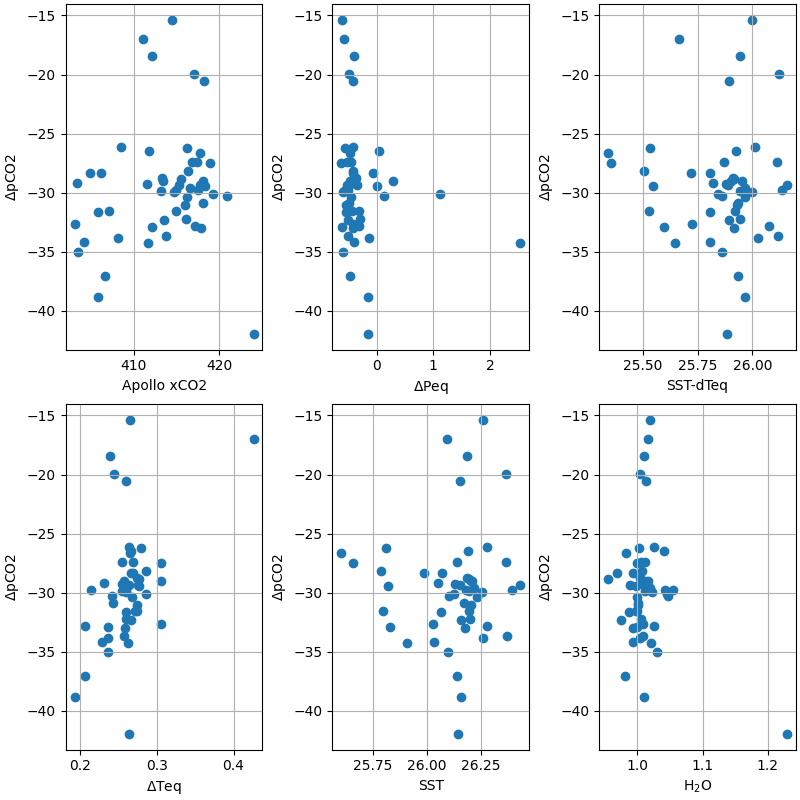

In [72]:
fig,ax = plt.subplots(2,3, figsize = (8,8), constrained_layout = True)
ax[0,0].scatter(apollo_re.xco2_corr.where(apollo_re.sample_source == 'seawater'),delta_sw)
ax[0,0].set_xlabel('Apollo xCO2')
ax[0,0].set_ylabel('$\Delta$pCO2')
#ax[0,0].set_ylim(-30,5)
ax[0,0].grid()

dPeq = ldeo_re.equilibrator_pressure - apollo_re.equilibrator_pressure
ax[0,1].scatter(dPeq,delta_sw)
ax[0,1].set_xlabel('$\Delta$Peq')
ax[0,1].set_ylabel('$\Delta$pCO2')
#ax[0,1].set_ylim(-30,5)
#ax[0,1].set_xlim(-0.5,0)
ax[0,1].grid()

dTeq = ldeo_re.equilibrator_temperature_sbe38.where(ldeo_re.sample_source == 'seawater')-apollo_re.apollo_sbe45_sea_water_temperature.where(apollo_re.sample_source == 'seawater')
ax[1,0].scatter(dTeq,delta_sw)
ax[1,0].set_xlabel('$\Delta$Teq')
ax[1,0].set_ylabel('$\Delta$pCO2')
#ax[1,0].set_ylim(-35,10)
#ax[1,0].set_xlim(-0.8,0)
ax[1,0].grid()

ax[1,1].scatter(apollo_re.sea_surface_temperature,delta_sw)
ax[1,1].set_xlabel('SST')
ax[1,1].set_ylabel('$\Delta$pCO2')
#ax[1,1].set_ylim(-30,5)
ax[1,1].grid()

ax[1,2].scatter(apollo_re.li7815_h2o,delta_sw)
ax[1,2].set_xlabel('H$_2$O')
ax[1,2].set_ylabel('$\Delta$pCO2')
#ax[1,1].set_ylim(-30,5)
ax[1,2].grid()

ax[0,2].scatter(apollo_re.sea_surface_temperature-dTeq,delta_sw)
ax[0,2].set_xlabel('SST-dTeq')
ax[0,2].set_ylabel('$\Delta$pCO2')
#ax[1,1].set_ylim(-30,5)
ax[0,2].grid()

plt.show()

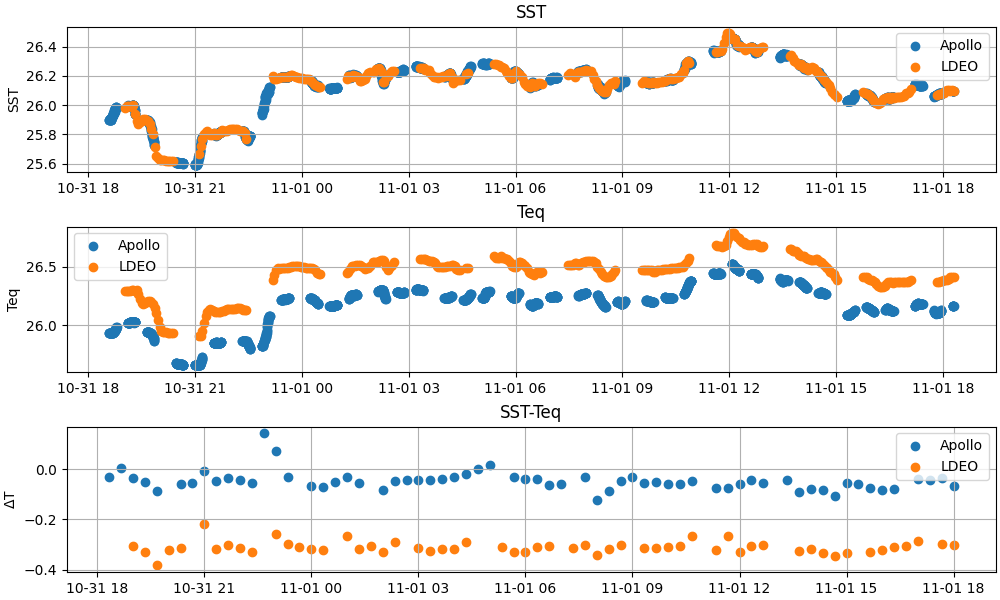

In [73]:
fig,ax = plt.subplots(3,1, figsize = (10,6), constrained_layout = True)
ax[0].scatter(apollo.time.where(apollo.sample_source == 'seawater'),apollo.sea_surface_temperature.where(apollo.sample_source == 'seawater'),label="Apollo")
ax[0].scatter(ldeo.time.where(ldeo.sample_source == 'seawater'),ldeo.sea_surface_temperature.where(ldeo.sample_source == 'seawater'),label="LDEO")
ax[0].set_ylabel('SST')
ax[0].set_title('SST')
ax[0].grid()
ax[0].legend()

ax[1].scatter(apollo.time.where(apollo.sample_source == 'seawater'),apollo.equilibrator_temperature_sbe45.where(apollo.sample_source == 'seawater'),label="Apollo")
ax[1].scatter(ldeo.time.where(ldeo.sample_source == 'seawater'),ldeo.equilibrator_temperature_sbe38.where(ldeo.sample_source == 'seawater'),label="LDEO")
ax[1].set_ylabel('Teq')
ax[1].set_title('Teq')
ax[1].grid()
ax[1].legend()

ax[2].scatter(apollo_re.time.where(apollo_re.sample_source == 'seawater'),(apollo_re.sea_surface_temperature.where(apollo_re.sample_source == 'seawater')-apollo_re.equilibrator_temperature_sbe45.where(apollo_re.sample_source == 'seawater')),label="Apollo")
ax[2].scatter(ldeo_re.time.where(ldeo_re.sample_source == 'seawater'),(ldeo_re.sea_surface_temperature.where(ldeo_re.sample_source == 'seawater')-ldeo_re.equilibrator_temperature_sbe38.where(ldeo_re.sample_source == 'seawater')),label="LDEO")
ax[2].set_ylabel('$\Delta$T')
ax[2].set_title('SST-Teq')
ax[2].grid()
ax[2].legend()

In [74]:
sd1_apollo = apollo.li7815_xco2.where(apollo.sample_source == 'sd1', drop=True)
sd1_apollo = sd1_apollo.values[~np.isnan(sd1_apollo.values)]

sd2_apollo = apollo.li7815_xco2.where(apollo.sample_source == 'sd2', drop=True)
sd2_apollo = sd2_apollo.values[~np.isnan(sd2_apollo.values)]

sd3_apollo = apollo.li7815_xco2.where(apollo.sample_source == 'sd3', drop=True)
sd3_apollo = sd3_apollo.values[~np.isnan(sd3_apollo.values)]

sd4_apollo = apollo.li7815_xco2.where(apollo.sample_source == 'sd4', drop=True)
sd4_apollo = sd4_apollo.values[~np.isnan(sd4_apollo.values)]

sd5_apollo = apollo.li7815_xco2.where(apollo.sample_source == 'sd5', drop=True)
sd5_apollo = sd5_apollo.values[~np.isnan(sd5_apollo.values)]

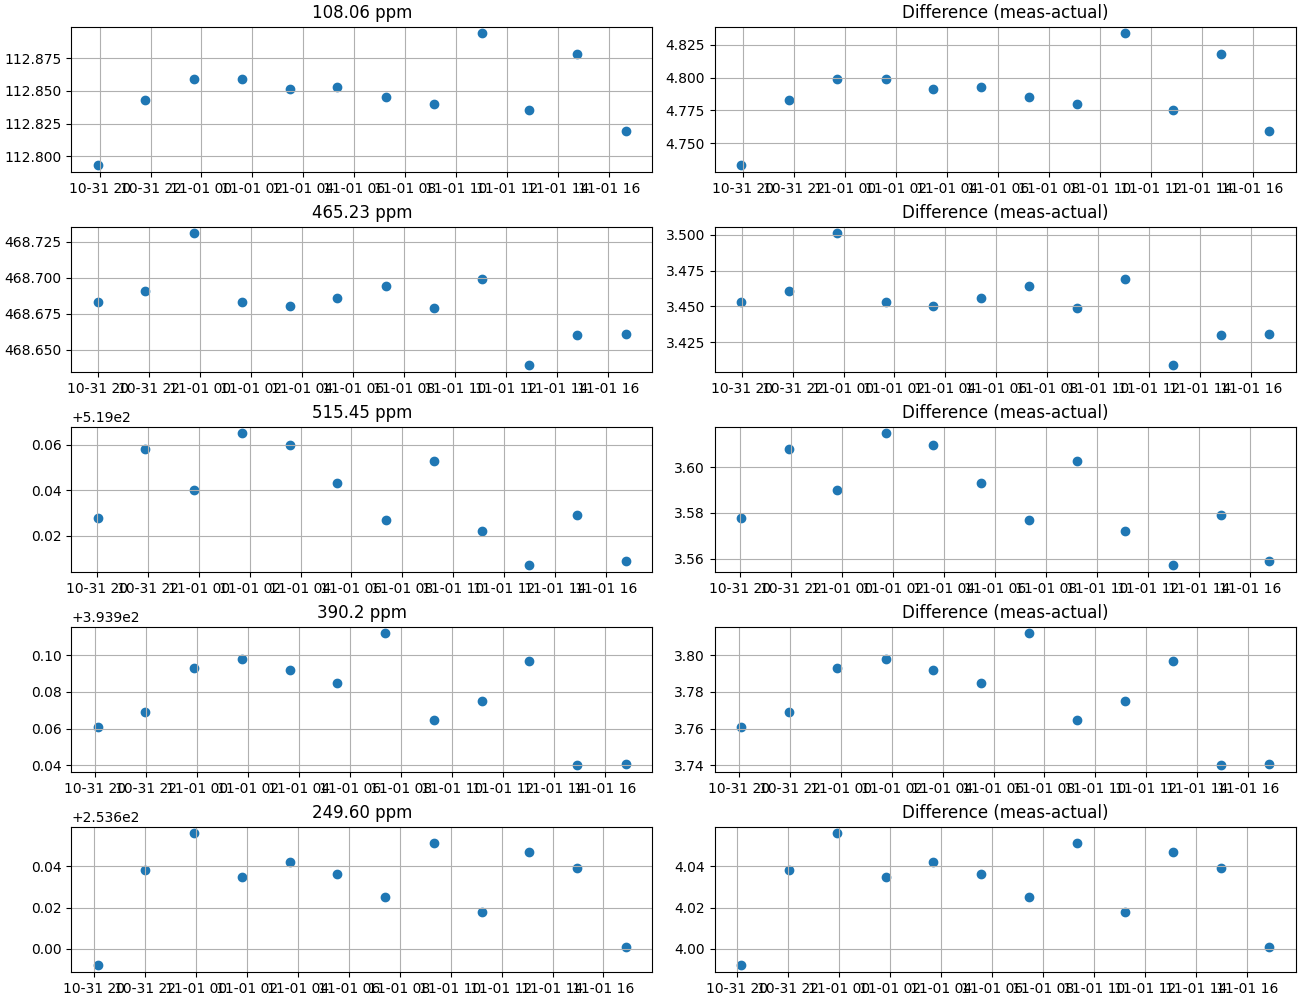

In [76]:
SD_1_time = apollo.time.where(apollo.sample_source == 'sd1')
SD_1_xco2 = apollo.li7815_xco2.where(apollo.sample_source == 'sd1')
SD_2_time = apollo.time.where(apollo.sample_source == 'sd2')
SD_2_xco2 = apollo.li7815_xco2.where(apollo.sample_source == 'sd2')
SD_3_time = apollo.time.where(apollo.sample_source == 'sd3')
SD_3_xco2 = apollo.li7815_xco2.where(apollo.sample_source == 'sd3')
SD_4_time = apollo.time.where(apollo.sample_source == 'sd4')
SD_4_xco2 = apollo.li7815_xco2.where(apollo.sample_source == 'sd4')
SD_5_time = apollo.time.where(apollo.sample_source == 'sd5')
SD_5_xco2 = apollo.li7815_xco2.where(apollo.sample_source == 'sd5')

fig,ax = plt.subplots(5,2, figsize = (13,10), constrained_layout = True)

ax[0,0].scatter(apollo.time.where(apollo.sample_source == 'sd1'),apollo.li7815_xco2.where(apollo.sample_source == 'sd1'),label='port 3')
ax[0,0].set_title('108.06 ppm')
ax[0,0].grid()
ax[0,1].scatter(apollo.time.where(apollo.sample_source == 'sd1'),apollo.li7815_xco2.where(apollo.sample_source == 'sd1')-108.06,label='port 3')
ax[0,1].set_title('Difference (meas-actual)')
ax[0,1].grid()

ax[1,0].scatter(apollo.time.where(apollo.sample_source == 'sd2'),apollo.li7815_xco2.where(apollo.sample_source == 'sd2'),label='port 4')
ax[1,0].set_title('465.23 ppm')
ax[1,0].grid()
ax[1,1].scatter(apollo.time.where(apollo.sample_source == 'sd2'),apollo.li7815_xco2.where(apollo.sample_source == 'sd2')-465.23,label='port 4')
ax[1,1].set_title('Difference (meas-actual)')
ax[1,1].grid()

ax[2,0].scatter(apollo.time.where(apollo.sample_source == 'sd3'),apollo.li7815_xco2.where(apollo.sample_source == 'sd3'),label='port 5')
ax[2,0].set_title('515.45 ppm')
ax[2,0].grid()
ax[2,1].scatter(apollo.time.where(apollo.sample_source == 'sd3'),apollo.li7815_xco2.where(apollo.sample_source == 'sd3')-515.45,label='port 5')
ax[2,1].set_title('Difference (meas-actual)')
ax[2,1].grid()

ax[3,0].scatter(apollo.time.where(apollo.sample_source == 'sd4'),apollo.li7815_xco2.where(apollo.sample_source == 'sd4'),label='port 6')
ax[3,0].set_title('390.2 ppm')
ax[3,0].grid()
ax[3,1].scatter(apollo.time.where(apollo.sample_source == 'sd4'),apollo.li7815_xco2.where(apollo.sample_source == 'sd4')-390.2,label='port 6')
ax[3,1].set_title('Difference (meas-actual)')
ax[3,1].grid()

ax[4,0].scatter(apollo.time.where(apollo.sample_source == 'sd5'),apollo.li7815_xco2.where(apollo.sample_source == 'sd5'),label='port 7')
ax[4,0].set_title('249.60 ppm')
ax[4,0].grid()
ax[4,1].scatter(apollo.time.where(apollo.sample_source == 'sd5'),apollo.li7815_xco2.where(apollo.sample_source == 'sd5')-249.60,label='port 7')
ax[4,1].set_title('Difference (meas-actual)')
ax[4,1].grid()

plt.show()

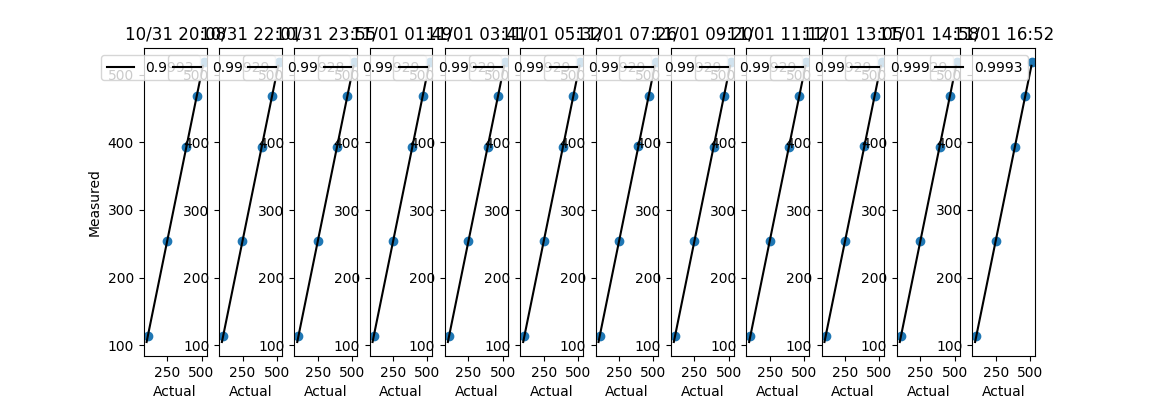

In [78]:
ind = np.where(np.any(~np.isnan(apollo.li7815_xco2.where(apollo.sample_source == 'sd5', drop=True)), axis=1))
indexes = list(ind[0])
times = apollo.time[indexes].values

from sklearn.metrics import mean_squared_error, r2_score

X = [108.06,465.23,515.45,390.2,249.6]

std_stats = pd.DataFrame(columns=['time', 'slope', 'y-int', 'r2'])
num_runs = len(times)

fig, ax = plt.subplots(1,num_runs, figsize=(11.5,4))
i = 0
n = 0
for m in range(0, num_runs):
    Y = [sd1_apollo[i], sd2_apollo[i], sd3_apollo[i], sd4_apollo[i], sd5_apollo[i]]
    slope, intercept = np.polyfit(X, Y, deg=1)
    std_stats.loc[i] = pd.to_datetime(str(times[i])).strftime('%m/%d %H:%M'), slope, intercept, round(r2_score(Y, X),5)
    Pts = [100, 510]
    if num_runs == 0:
        ax.plot(Pts, np.multiply(Pts, slope) + intercept, color='black', label=round(r2_score(Y, X),5))
        ax.scatter(X, Y)
        ax.set_title(pd.to_datetime(str(times[i])).strftime('%m/%d %H:%M'))
        ax.legend()
        ax.set_ylabel('Measured')
        ax.set_xlabel('Actual')
    else:
        ax[m].plot(Pts, np.multiply(Pts, slope) + intercept, color='black', label=round(r2_score(Y, X),5))
        ax[m].scatter(X, Y)
        ax[m].set_title(pd.to_datetime(str(times[i])).strftime('%m/%d %H:%M'))
        ax[m].legend()
        ax[m].set_xlabel('Actual')
        i+=1
std_stats

ax[0].set_ylabel('Measured')

plt.show()

In [79]:
plt.close('all')